## Import Libraries and Data

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Import data

In [37]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')

## EDA 

### Train information

In [38]:
print(f"Shape {train_df.shape}")
print(f"Information; \n{train_df.info()}")
print(f"Describe: \n{train_df.describe()}")
print(train_df.head())

Shape (1460, 81)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int6

### Numerical vs Categorical (Train)

In [39]:
numerical_col = train_df.select_dtypes(['float64', 'int64']).columns
categorical_col = train_df.select_dtypes(['object']).columns

print(f"Numeric columns:(Count - {len(numerical_col)}) \n{numerical_col} ")
print(f"\nCategorical columns: (Count - {len(categorical_col)}) \n{categorical_col}")

Numeric columns:(Count - 38) 
Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object') 

Categorical columns: (Count - 43) 
Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 

### Test Information

In [40]:
print(f"Shape {test_df.shape}")
print(f"Information; \n{test_df.info()}")
print(f"Describe: \n{test_df.describe()}")
print(test_df.head())

Shape (1459, 80)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int6

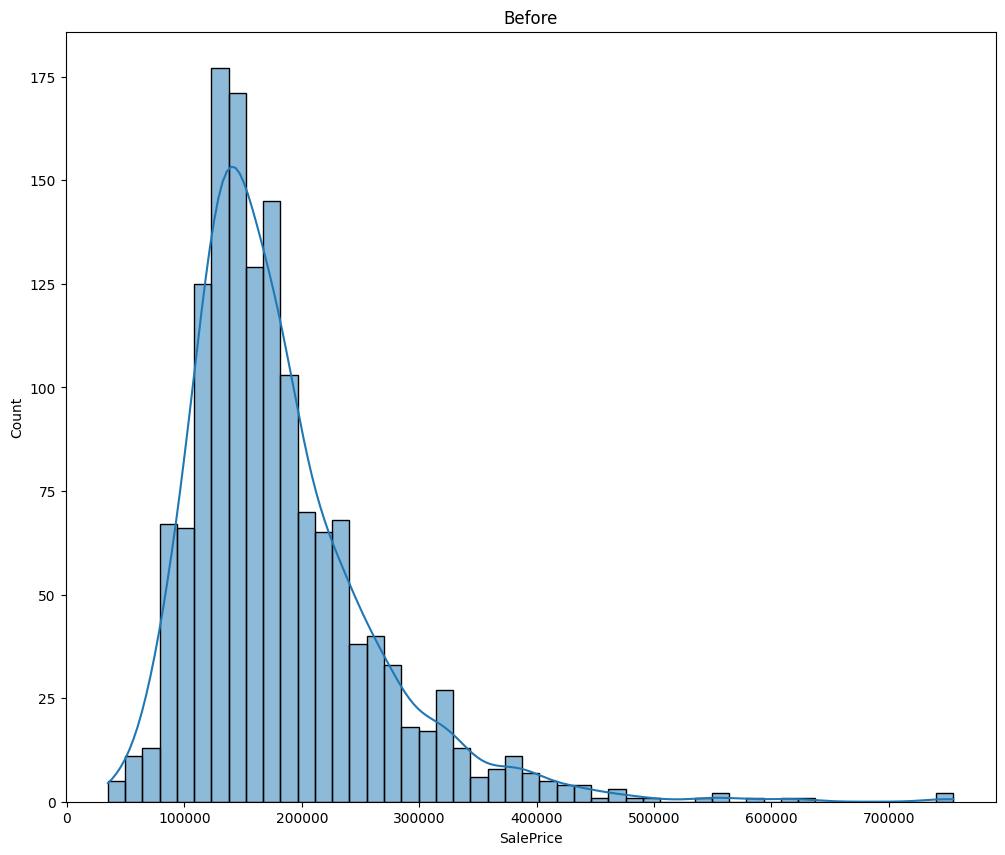

In [41]:
plt.figure(figsize=(12,10))

sns.histplot(
    data=train_df,
    x = 'SalePrice',
    kde=True
)
plt.title("Before")
plt.show()

## SalePrice Distribution Analysis

## Visual Inspection
The histogram for **SalePrice** shows the distribution of house prices within the dataset. Based on the visualization, we can observe the following:

* **Shape:** The distribution is **Right-Skewed** (Positively Skewed).
    * The "tail" on the right side is longer, stretching towards higher values (up to $750,000$).
    * Most data points are clustered in the low-to-mid range ($100,000$ to $300,000$).
* **Peak (Mode):** The most frequent house prices occur between **$130,000** and **$160,000**.
* **Outliers:** There are visible outliers on the far right, representing luxury properties that are significantly more expensive than the average home.

---

## Statistical Implications
In a right-skewed distribution like this:
1.  **Mean > Median > Mode:** The average price is pulled higher by the expensive outliers.
2.  **Machine Learning:** Linear models may struggle with this skewness.

### Recommended Actions
* **Log Transformation:** Applying `np.log1p(df['SalePrice'])` will help normalize the distribution.
* **Feature Scaling:** Consider robust scaling if outliers are kept, as they heavily influence the standard deviation.

---
*Analysis generated for EDA (Exploratory Data Analysis) report.*

### Log SalePrice

In [42]:
train_df['SalePrice'] = np.log1p(train_df['SalePrice'])

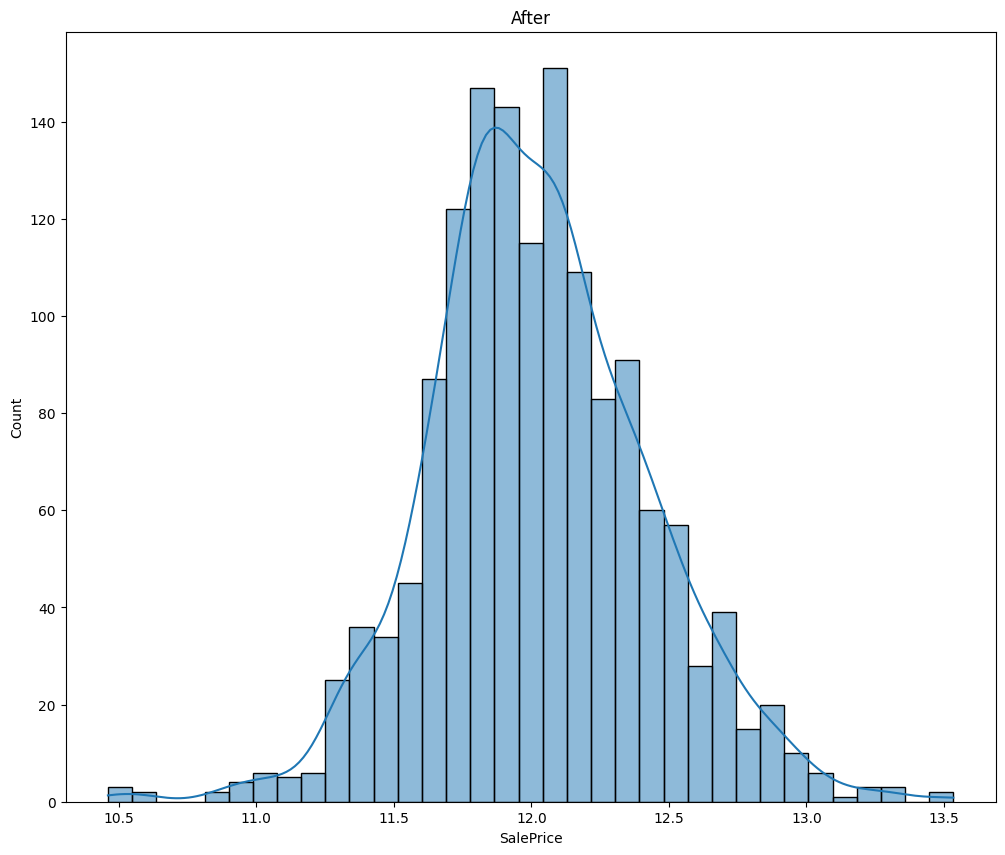

In [43]:
plt.figure(figsize=(12,10))

sns.histplot(
    data=train_df,
    x = 'SalePrice',
    kde=True
)
plt.title("After")
plt.show()

## Result After Log Transformation

After applying `np.log1p`, the distribution of **SalePrice** has significantly improved:

* **Symmetry:** The distribution now closely resembles a **Normal Distribution** (Bell Curve).
* **Skewness Reduction:** The long right tail has been pulled in, and the data is now centered around the mean (approx. $12.0$).
* **Homoscedasticity:** This transformation helps in stabilizing the variance across the dataset, which is a key assumption for many Machine Learning algorithms.

### Conclusion
The target variable is now well-conditioned for linear modeling. By normalizing the target, we reduce the risk of the model being biased toward high-priced outliers, leading to more robust and accurate predictions.

Top 15 Features highly correlated with SalePrice:
SalePrice       1.000000
OverallQual     0.817185
GrLivArea       0.700927
GarageCars      0.680625
GarageArea      0.650888
TotalBsmtSF     0.612134
1stFlrSF        0.596981
FullBath        0.594771
YearBuilt       0.586570
YearRemodAdd    0.565608
GarageYrBlt     0.541073
TotRmsAbvGrd    0.534422
Fireplaces      0.489450
MasVnrArea      0.430809
BsmtFinSF1      0.372023
LotFrontage     0.355879
Name: SalePrice, dtype: float64


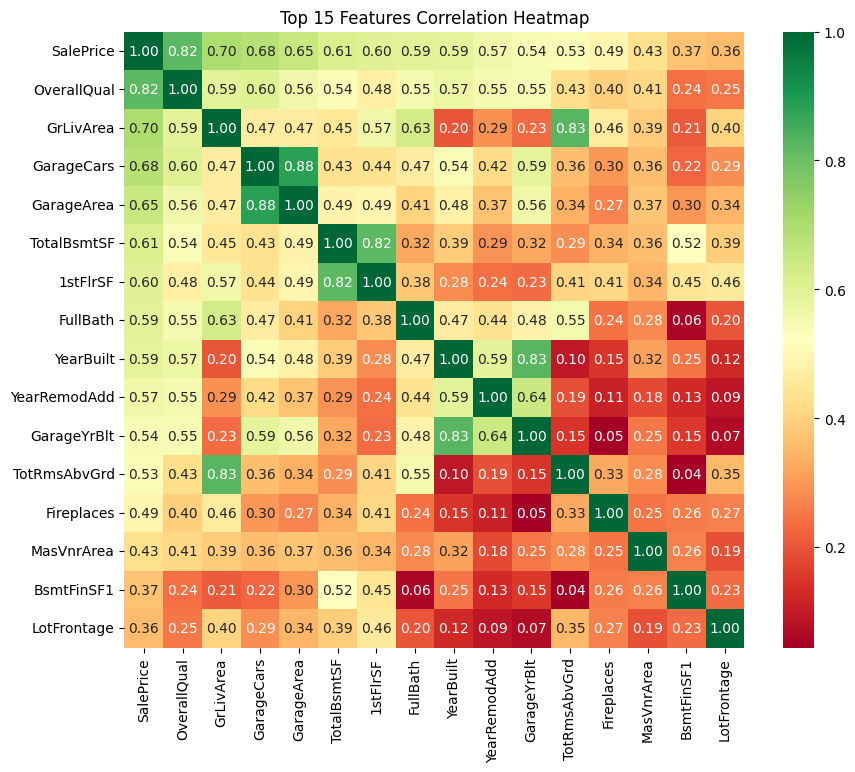

In [44]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


corr_matrix = train_df.corr(numeric_only=True)

top_15_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(16) 

print("Top 15 Features highly correlated with SalePrice:")
print(top_15_features)

cols = top_15_features.index
plt.figure(figsize=(10, 8))
sns.heatmap(train_df[cols].corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title('Top 15 Features Correlation Heatmap')
plt.show()

## Beyond Numerical Correlation: Handling Categorical Features

While the **Heatmap** provides a great overview of numerical relationships, it ignores **Categorical Features** (Strings). Relying solely on numerical columns can lead to missing critical information.

### Warning on Multicollinearity
Looking at the current heatmap, some features are "redundant":
* **GarageCars** & **GarageArea** ($r=0.88$)
* **TotalBsmtSF** & **1stFlrSF** ($r=0.82$)
* **TotRmsAbvGrd** & **GrLivArea** ($r=0.83$)

*Decision:* To avoid overfitting and multicollinearity, we should consider keeping only one feature from each highly correlated pair.

### Missing Value

In [45]:
missing_count = train_df.isnull().sum()
missing_pct = (missing_count / len(train_df)) * 100

missing_data = pd.concat([missing_count, missing_pct], axis=1, keys=['Total', 'Percent'])

missing_data = missing_data[missing_data['Total'] > 0].sort_values(ascending=False, by='Total')

print(missing_data)

              Total    Percent
PoolQC         1453  99.520548
MiscFeature    1406  96.301370
Alley          1369  93.767123
Fence          1179  80.753425
MasVnrType      872  59.726027
FireplaceQu     690  47.260274
LotFrontage     259  17.739726
GarageType       81   5.547945
GarageYrBlt      81   5.547945
GarageFinish     81   5.547945
GarageQual       81   5.547945
GarageCond       81   5.547945
BsmtExposure     38   2.602740
BsmtFinType2     38   2.602740
BsmtQual         37   2.534247
BsmtCond         37   2.534247
BsmtFinType1     37   2.534247
MasVnrArea        8   0.547945
Electrical        1   0.068493


In [46]:
missing_count = test_df.isnull().sum()
missing_pct = (missing_count / len(test_df)) * 100

missing_data = pd.concat([missing_count, missing_pct], axis=1, keys=['Total', 'Percent'])

missing_data = missing_data[missing_data['Total'] > 0].sort_values(ascending=False, by='Total')

print(missing_data)

              Total    Percent
PoolQC         1456  99.794380
MiscFeature    1408  96.504455
Alley          1352  92.666210
Fence          1169  80.123372
MasVnrType      894  61.274846
FireplaceQu     730  50.034270
LotFrontage     227  15.558602
GarageQual       78   5.346127
GarageCond       78   5.346127
GarageYrBlt      78   5.346127
GarageFinish     78   5.346127
GarageType       76   5.209047
BsmtCond         45   3.084304
BsmtQual         44   3.015764
BsmtExposure     44   3.015764
BsmtFinType1     42   2.878684
BsmtFinType2     42   2.878684
MasVnrArea       15   1.028101
MSZoning          4   0.274160
Functional        2   0.137080
BsmtFullBath      2   0.137080
Utilities         2   0.137080
BsmtHalfBath      2   0.137080
Exterior1st       1   0.068540
Exterior2nd       1   0.068540
TotalBsmtSF       1   0.068540
BsmtUnfSF         1   0.068540
BsmtFinSF2        1   0.068540
BsmtFinSF1        1   0.068540
KitchenQual       1   0.068540
GarageArea        1   0.068540
GarageCa

## Feature Engineering

### Merge train and test

In [47]:
train_y = train_df['SalePrice']
test_ids = test_df['Id']
n_train = train_df.shape[0]

In [48]:
all_features = pd.concat([
    train_df.drop(['Id', 'SalePrice'], axis=1), 
    test_df.drop(['Id'], axis=1)
]).reset_index(drop=True)

### Missing Value Handling

In [49]:
missing_value = all_features.isnull().sum()
print(missing_value[missing_value > 0])

MSZoning           4
LotFrontage      486
Alley           2721
Utilities          2
Exterior1st        1
Exterior2nd        1
MasVnrType      1766
MasVnrArea        23
BsmtQual          81
BsmtCond          82
BsmtExposure      82
BsmtFinType1      79
BsmtFinSF1         1
BsmtFinType2      80
BsmtFinSF2         1
BsmtUnfSF          1
TotalBsmtSF        1
Electrical         1
BsmtFullBath       2
BsmtHalfBath       2
KitchenQual        1
Functional         2
FireplaceQu     1420
GarageType       157
GarageYrBlt      159
GarageFinish     159
GarageCars         1
GarageArea         1
GarageQual       159
GarageCond       159
PoolQC          2909
Fence           2348
MiscFeature     2814
SaleType           1
dtype: int64


### Numerical missing handling

In [50]:
all_features['LotFrontage'] = all_features['LotFrontage'].fillna(all_features['LotFrontage'].median())
all_features['GarageYrBlt'] = all_features['GarageYrBlt'].fillna(all_features['YearBuilt'])
col_fill0 = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'BsmtFullBath', 'BsmtHalfBath', 'GarageCars', 'GarageArea']
all_features[col_fill0] = all_features[col_fill0].fillna(0)

In [51]:
# Check after fix
numerical_cols = all_features.select_dtypes(include=['int64', 'float64']).columns
missing_num = all_features[numerical_cols].isnull().sum()
print(missing_num[missing_num > 0])

Series([], dtype: int64)


### Categorical missing handling


In [52]:
categorical_cols = all_features.select_dtypes(include=['object']).columns
all_features[categorical_cols] = all_features[categorical_cols].fillna('None')

In [53]:
missing_cat = all_features[categorical_cols].isnull().sum()
print(missing_cat[missing_cat > 0])

Series([], dtype: int64)


### Create new features

In [54]:
all_features['TotalSF'] = all_features['TotalBsmtSF'] + all_features['1stFlrSF'] + all_features['2ndFlrSF']
all_features['TotalBath'] = (
    all_features['FullBath'] + 
    (0.5 * all_features['HalfBath']) + 
    all_features['BsmtFullBath'] + 
    (0.5 * all_features['BsmtHalfBath'])
)
all_features['HouseAge'] = all_features['YrSold'] - all_features['YearBuilt']
all_features['TotalPorchSF'] = (
    all_features['OpenPorchSF'] + 
    all_features['EnclosedPorch'] + 
    all_features['3SsnPorch'] + 
    all_features['ScreenPorch'] + 
    all_features['WoodDeckSF']
)

In [55]:
binary_cols = [col for col in categorical_cols if all_features[col].nunique() <= 2]
multi_cols = [col for col in categorical_cols if all_features[col].nunique() > 2]


print(f"Binary Columns ({len(binary_cols)}): {binary_cols}")
print(f"Multivariate Columns ({len(multi_cols)}): {multi_cols}")

Binary Columns (2): ['Street', 'CentralAir']
Multivariate Columns (41): ['MSZoning', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


### Binary Columns encode

In [56]:
from sklearn.preprocessing import LabelEncoder

all_features['CentralAir'] = all_features['CentralAir'].map({'N': 0, 'Y': 1})
all_features['Street'] = all_features['Street'].map({'Grvl': 0, 'Pave': 1})

le = LabelEncoder()
all_features['Utilities'] = le.fit_transform(all_features['Utilities'])

### Multivariate Columns encode

In [57]:
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC']

for col in qual_cols:
    all_features[col] = all_features[col].map(qual_map)

all_features['BsmtExposure'] = all_features['BsmtExposure'].map({'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0})
all_features['LotShape'] = all_features['LotShape'].map({'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1})
all_features['LandSlope'] = all_features['LandSlope'].map({'Gtl': 3, 'Mod': 2, 'Sev': 1})
all_features['GarageFinish'] = all_features['GarageFinish'].map({'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0})

In [58]:
all_features['MSSubClass'] = all_features['MSSubClass'].astype(str)
all_features['MoSold'] = all_features['MoSold'].astype(str)
all_features['YrSold'] = all_features['YrSold'].astype(str)

all_features = pd.get_dummies(all_features, dtype=int)

### Log Transform Skewed Numerical Features

In [59]:
from scipy.stats import skew

numerical_cols = all_features.select_dtypes(include=['int64', 'float64']).columns
skewed_feats = all_features[numerical_cols].apply(lambda x: skew(x)).sort_values(ascending=False)

high_skew_cols = skewed_feats[abs(skewed_feats) > 0.75].index

all_features[high_skew_cols] = np.log1p(all_features[high_skew_cols])

### Drop some columns

In [60]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.005) 
all_features_reduced = selector.fit_transform(all_features)

selected_cols = all_features.columns[selector.get_support()]
all_features = all_features[selected_cols]
print(f"{all_features.shape[1]}")

202


In [61]:
cols_to_drop = ['GarageArea', '1stFlrSF', 'GarageYrBlt', 'TotRmsAbvGrd']
all_features = all_features.drop(columns=cols_to_drop)

print(f"The maximum number of columns after removal is linear.: {all_features.shape[1]}")

The maximum number of columns after removal is linear.: 198


### Split data, scaler, and convert into tensor type

In [63]:
from sklearn.preprocessing import StandardScaler
import torch

train_features = all_features[:n_train].copy()
test_features = all_features[n_train:].copy()
train_labels = train_df['SalePrice'].values

scaler = StandardScaler()

train_features_scaled = scaler.fit_transform(train_features)
test_features_scaled = scaler.transform(test_features)

X_train = torch.tensor(train_features_scaled, dtype=torch.float32)
y_train = torch.tensor(train_labels, dtype=torch.float32)
X_test = torch.tensor(test_features_scaled, dtype=torch.float32)

## Custom Dataset Class

In [68]:
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(X_train, y_train, test_size=0.1, random_state=42)

print(f"Train: {X_train_final.shape}")
print(f"Val: {X_val.shape}")


class HousePriceDataset(Dataset):
    def __init__(self, X, y=None):
        self.X = X
        self.y = y
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        features = self.X[index]
        
        if self.y is not None:
            label = self.y[index]
            return features, label
    
        return features

train_dataset = HousePriceDataset(X_train_final, y_train_final)
val_dataset   = HousePriceDataset(X_val, y_val)
test_dataset  = HousePriceDataset(X_test)
    
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

Train: torch.Size([1314, 198])
Val: torch.Size([146, 198])


In [71]:
features, labels = next(iter(train_loader))

print(features.shape)
print(labels.shape)
print(features.dtype)

torch.Size([64, 198])
torch.Size([64])
torch.float32


## Model definition

In [79]:
from torch import nn

class HousePriceModel(nn.Module):
    
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128, 64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64, 32)
        self.bn3 = nn.BatchNorm1d(32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(0.2)
        
    def forward(self, x):
        # Layer 1
        x = self.fc1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.drop(x)
        
        # Layer 2
        x = self.fc2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.drop(x)
        
        # Layer 3
        x = self.fc3(x)
        x = self.bn3(x)
        x = self.relu(x)
        
        x = self.fc4(x)
        return x
        
    
    def count_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

## Train Loop


In [85]:
import torch.optim as optim

model = HousePriceModel(X_train_final.shape[1])
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr = 0.01, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

def calculate_rmsle(y_true, y_pred):
    mse = nn.functional.mse_loss(y_pred, y_true)
    return torch.sqrt(mse).item()

class EarlyStopping:
    def __init__(self, patience = 15, delta = 0, verbose = True, path='best_model.pth'):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.path = path
        
        self.counter = 0
        self.best_score = None
        self.early_stop = False
    
    def __call__(self, val_rmsle, model):
        if self.best_score is None:
            self.best_score = val_rmsle
            self.save_checkpoint(model)
        elif val_rmsle > self.best_score - self.delta:
            self.counter += 1
            print(f"Early Stopping counter: {self.counter} / {self.patience}")
            if self.counter > self.patience:
                self.early_stop = True
        else:
            self.best_score = val_rmsle
            self.save_checkpoint(model)
            self.counter = 0
            
    
    def save_checkpoint(self, model):
        torch.save(model.state_dict(), self.path)
    

In [86]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    
    for features, target in loader:
        features, target = features.to(device), target.to(device)
        
        optimizer.zero_grad()
        outputs = model(features)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
    return total_loss / len(loader)

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for features, target in loader:
            features, target = features.to(device), target.to(device)
            outputs = model(features)
            loss = criterion(outputs, target)
            
            total_loss += loss.item()
    
    avg_mse = total_loss / len(loader)
    return avg_mse, np.sqrt(avg_mse)



In [87]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
early_stopping = EarlyStopping(patience=15)

for epoch in range(100):
    train_mse = train_epoch(model, train_loader, criterion, optimizer, device)
    val_mse, val_rmsle = eval_epoch(model, val_loader, criterion, device)
    
    print(f"Epoch {epoch+1}: Train MSE = {train_mse:.4f}, Val MSE = {val_mse:.4f}  Val RMSLE = {val_rmsle:.4f}")
    
    scheduler.step(val_rmsle)
    
    early_stopping(val_rmsle, model)
    if early_stopping.early_stop:
        print("Reach limit")
        break

Epoch 1: Train MSE = 113.2352, Val MSE = 68.6312  Val RMSLE = 8.2844
Epoch 2: Train MSE = 37.5947, Val MSE = 14.8644  Val RMSLE = 3.8554
Epoch 3: Train MSE = 2.2317, Val MSE = 0.6544  Val RMSLE = 0.8089
Epoch 4: Train MSE = 1.0623, Val MSE = 0.8964  Val RMSLE = 0.9468
Early Stopping counter: 1 / 15
Epoch 5: Train MSE = 0.6889, Val MSE = 0.4273  Val RMSLE = 0.6537
Epoch 6: Train MSE = 0.5543, Val MSE = 0.6322  Val RMSLE = 0.7951
Early Stopping counter: 1 / 15
Epoch 7: Train MSE = 0.4380, Val MSE = 0.4429  Val RMSLE = 0.6655
Early Stopping counter: 2 / 15
Epoch 8: Train MSE = 0.4312, Val MSE = 0.3858  Val RMSLE = 0.6212
Epoch 9: Train MSE = 0.4653, Val MSE = 0.3228  Val RMSLE = 0.5681
Epoch 10: Train MSE = 0.3537, Val MSE = 0.3962  Val RMSLE = 0.6294
Early Stopping counter: 1 / 15
Epoch 11: Train MSE = 0.3457, Val MSE = 0.3401  Val RMSLE = 0.5832
Early Stopping counter: 2 / 15
Epoch 12: Train MSE = 0.2998, Val MSE = 0.2951  Val RMSLE = 0.5432
Epoch 13: Train MSE = 0.3391, Val MSE = 0.414